In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Bike Sales Data.csv to Bike Sales Data.csv


In [4]:
df=pd.read_csv("Bike Sales Data.csv")


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1026 entries, 0 to 1025
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1026 non-null   int64  
 1   Marital Status    1026 non-null   object 
 2   Gender            1026 non-null   object 
 3   Income            1026 non-null   float64
 4   Children          1026 non-null   int64  
 5   Education         1026 non-null   object 
 6   Occupation        1026 non-null   object 
 7   Home Owner        1026 non-null   object 
 8   Cars              1026 non-null   int64  
 9   Commute Distance  1026 non-null   object 
 10  Region            1026 non-null   object 
 11  Age               1026 non-null   int64  
 12  Purchased Bike    1026 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 104.3+ KB


In [6]:
df.describe()

,ID,Income,Children,Cars,Age
count,1026.000000,1026.000000,1026.000000,1026.000000,1026.000000
mean,19969.196881,56208.576998,1.892788,1.437622,44.138402
std,5332.672942,31293.284007,1.626670,1.125538,11.349282
min,11000.000000,10000.000000,0.000000,0.000000,25.000000
25%,15304.750000,30000.000000,0.000000,1.000000,35.000000
50%,19744.000000,60000.000000,2.000000,1.000000,43.000000
75%,24457.750000,70000.000000,3.000000,2.000000,52.000000
max,29447.000000,170000.000000,5.000000,4.000000,89.000000


In [7]:
print(df.dtypes)

ID                    int64
Marital Status       object
Gender               object
Income              float64
Children              int64
Education            object
Occupation           object
Home Owner           object
Cars                  int64
Commute Distance     object
Region               object
Age                   int64
Purchased Bike       object
dtype: object


In [8]:
print(df.isnull().sum())

ID                  0
Marital Status      0
Gender              0
Income              0
Children            0
Education           0
Occupation          0
Home Owner          0
Cars                0
Commute Distance    0
Region              0
Age                 0
Purchased Bike      0
dtype: int64


In [9]:
df.duplicated().sum()

np.int64(26)

In [10]:
duplicate_id_rows = df[df['ID'].duplicated(keep=False)].sort_values('ID')
print("Rows involved in duplicate IDs:", duplicate_id_rows.shape[0])
duplicate_id_rows.head(6)

Rows involved in duplicate IDs: 52


,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
12,11434,M,M,170000.0,5,Partial College,Professional,Yes,0,0-1 Miles,Europe,55,No
1004,11434,M,M,170000.0,5,Partial College,Professional,Yes,0,0-1 Miles,Europe,55,No
25,12590,S,M,30000.0,1,Bachelors,Clerical,Yes,0,0-1 Miles,Europe,63,No
1017,12590,S,M,30000.0,1,Bachelors,Clerical,Yes,0,0-1 Miles,Europe,63,No
1009,12610,M,F,30000.0,1,Bachelors,Clerical,Yes,0,0-1 Miles,Europe,47,No
17,12610,M,F,30000.0,1,Bachelors,Clerical,Yes,0,0-1 Miles,Europe,47,No


In [11]:
df.shape

(1026, 13)

In [12]:
df = df.drop_duplicates()
print("Remaining duplicates:", df.duplicated().sum())
print("New shape:", df.shape)

Remaining duplicates: 0
New shape: (1000, 13)


In [13]:
df = df.reset_index(drop=True)

In [14]:
print(df['Purchased Bike'].value_counts())
print()
print("percentage :",df['Purchased Bike'].value_counts(normalize=True).round(3)*100)

Purchased Bike
No     519
Yes    481
Name: count, dtype: int64

percentage : Purchased Bike
No     51.9
Yes    48.1
Name: proportion, dtype: float64


In [15]:
def income_bracket(income):
    if income <= 30000:
        return "average"
    elif income <= 60000:
        return "good"
    elif income <= 90000:
        return "high"
    else:
        return "very High (90k+)"

df['Income Bracket'] = df['Income'].apply(income_bracket)

In [16]:
def age_group(age):
  if age < 29:
    return "less than 29"
  elif age < 39:
    return "less than 39"
  elif age < 49:
    return "less than 49"
  else:
    return "greater than 49"

df['Age Group'] = df['Age'].apply(age_group)

In [17]:
df['Purchased Bike Flag'] = (df['Purchased Bike'] == 'Yes').astype(int)

In [18]:
region_rate = (df.groupby('Region')['Purchased Bike Flag'].mean() * 100).sort_values(ascending=True)
print(region_rate.round(1))

Region
North America    43.3
Europe           49.3
Pacific          58.9
Name: Purchased Bike Flag, dtype: float64


In [19]:
martial_rate=(df.groupby('Marital Status')['Purchased Bike Flag'].mean()*100).sort_values(ascending=False)
print()
print(martial_rate.round(1))




Marital Status
S    54.1
M    42.9
Name: Purchased Bike Flag, dtype: float64


In [20]:
homeowner_rate = (df.groupby(['Home Owner','Cars'])['Purchased Bike Flag'].count() * 100).sort_values(ascending=False).unstack()
print()
print(homeowner_rate.round(1))


Cars            0      1      2     3     4
Home Owner                                 
No           4700  10800  11500  3100  1600
Yes         20000  15900  22700  5400  4300


In [21]:
occupation_rate = (df.groupby(['Occupation','Income Bracket'])['Purchased Bike Flag'].mean() * 100).sort_values(ascending=False)
print(occupation_rate.round(1).unstack())

print()
education_rate = (df.groupby(['Education','Income Bracket'])['Purchased Bike Flag'].mean() * 100).sort_values(ascending=False)
print(education_rate.round(1).unstack())



Income Bracket  average  good   high  very High (90k+)
Occupation                                            
Clerical           40.0  70.2    NaN               NaN
Management          NaN  34.9   44.6              44.6
Manual             45.3   NaN  100.0             100.0
Professional        NaN  56.7   52.6              53.8
Skilled Manual     26.7  49.7   47.3               NaN

Income Bracket       average  good  high  very High (90k+)
Education                                                 
Bachelors               59.1  59.2  54.5              38.9
Graduate Degree         42.1  58.9  53.2              50.0
High School             41.0  40.3  60.9              50.0
Partial College         39.8  50.0  41.1              51.7
Partial High School     22.6  42.9   8.3             100.0


Count bike by Gender


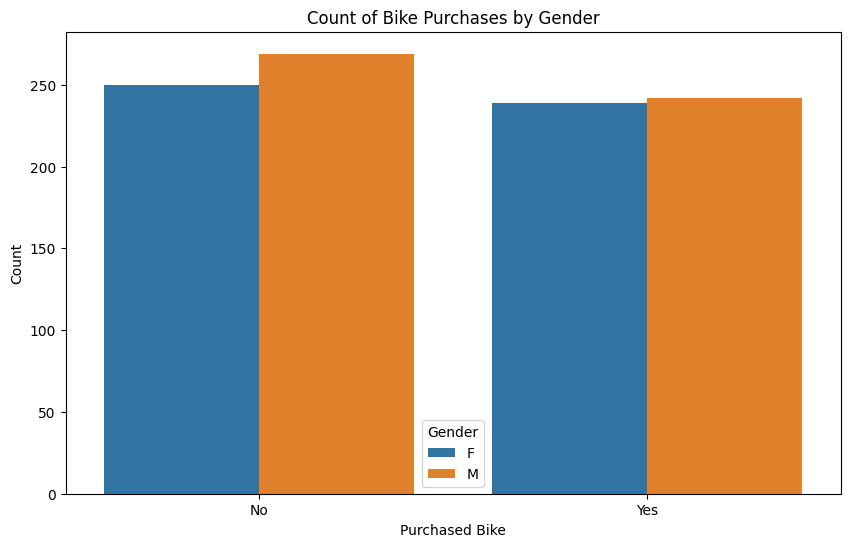

In [22]:
# Calculate counts of 'Purchased Bike' for each 'Gender'
bike_purchase_gender_counts = df.groupby(['Purchased Bike', 'Gender']).size().reset_index(name='count')

plt.figure(figsize=(10,6))
sns.barplot(data=bike_purchase_gender_counts, x='Purchased Bike', y='count', hue='Gender')
plt.title("Count of Bike Purchases by Gender")
plt.xlabel("Purchased Bike")
plt.ylabel("Count")
plt.show()

Income Distribution by Gender and Bike Purchase

Text(0, 0.5, 'Income')

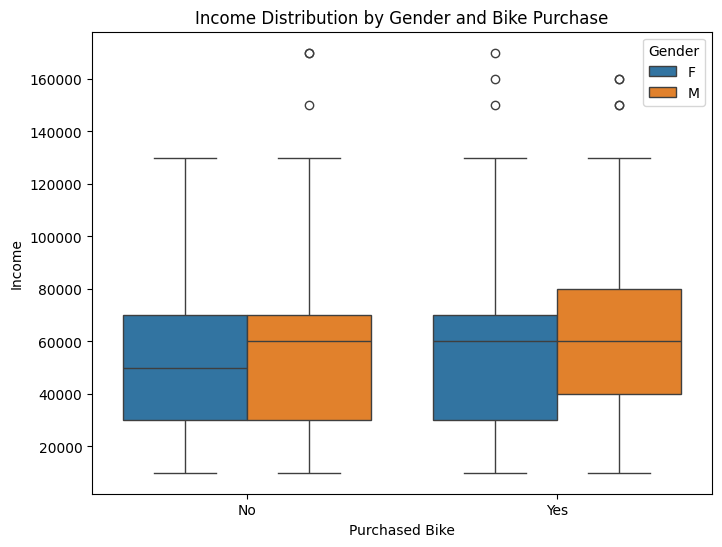

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='Purchased Bike',y="Income",hue="Gender")
plt.title("Income Distribution by Gender and Bike Purchase")
plt.xlabel("Purchased Bike")
plt.ylabel("Income")

Purchased Bike by Marital Status

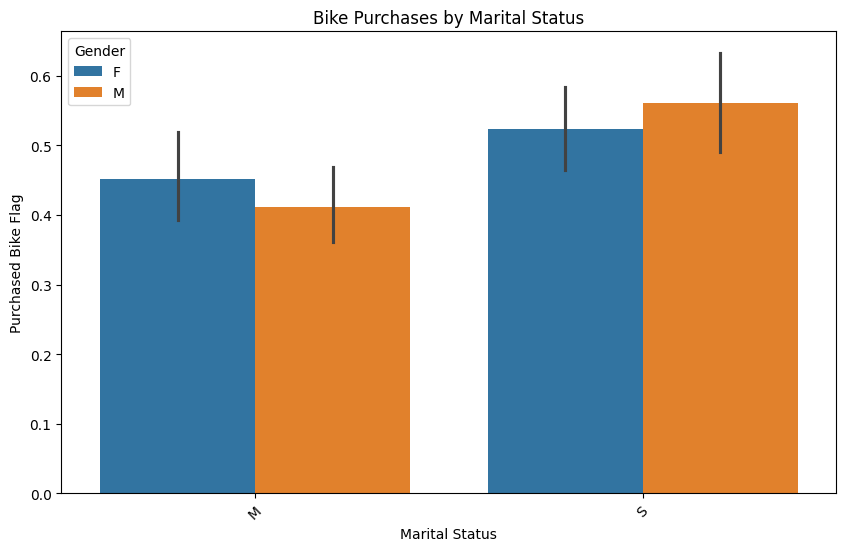

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Marital Status',
    y='Purchased Bike Flag',
    hue='Gender'
)

plt.title("Bike Purchases by Marital Status")
plt.xticks(rotation=45)
plt.show()

Purchased by Occupation

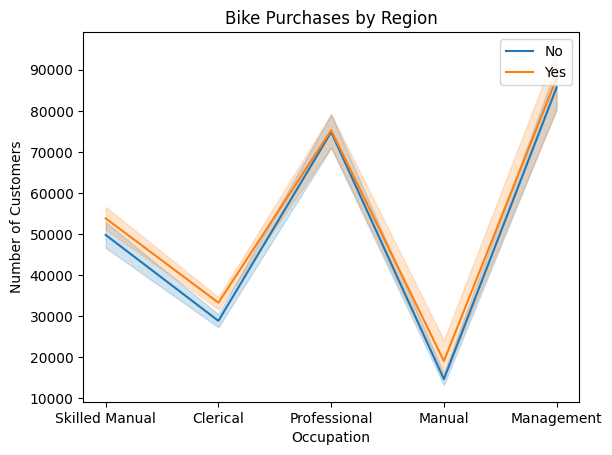

In [25]:
rg = pd.crosstab(df["Occupation"], df["Purchased Bike"])
sns.lineplot(data=df,x="Occupation",y="Income",hue="Purchased Bike")
plt.title("Bike Purchases by Region")
plt.ylabel("Number of Customers")
plt.legend(loc=1)
plt.show()

Region vs Purchased Bike

Text(0, 0.5, 'Purchased Bike')

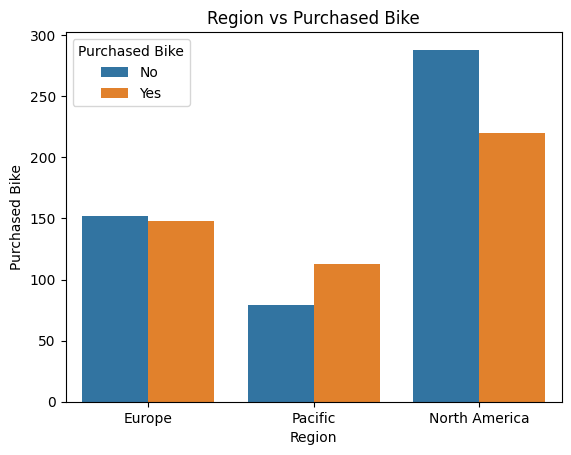

In [26]:
sns.countplot(data=df,x="Region",hue="Purchased Bike")
plt.title("Region vs Purchased Bike")
plt.xlabel("Region")
plt.ylabel("Purchased Bike")

Compared to other regions, North America recorded the highest number of bike purchases.

Income by Education

<Axes: xlabel='Education', ylabel='Income'>

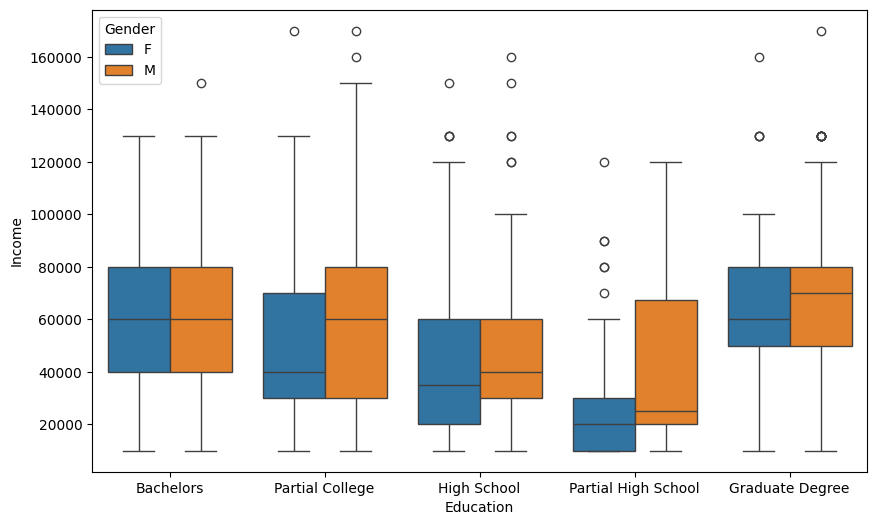

In [27]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Education',
    y='Income',
    hue='Gender',
    data=df)

<Axes: >

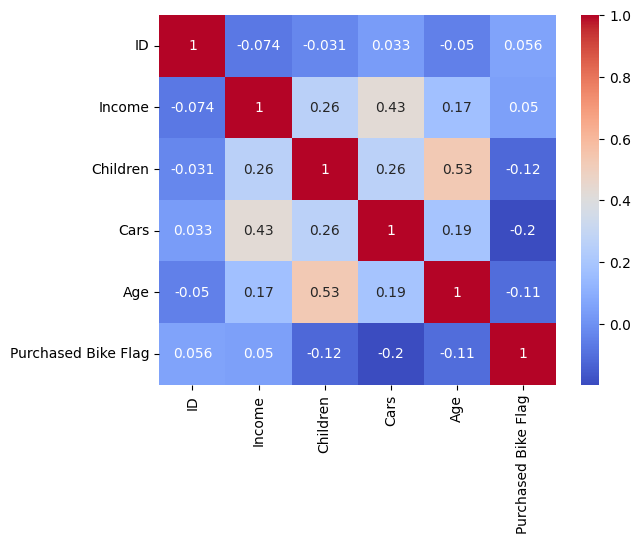

In [28]:
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm')

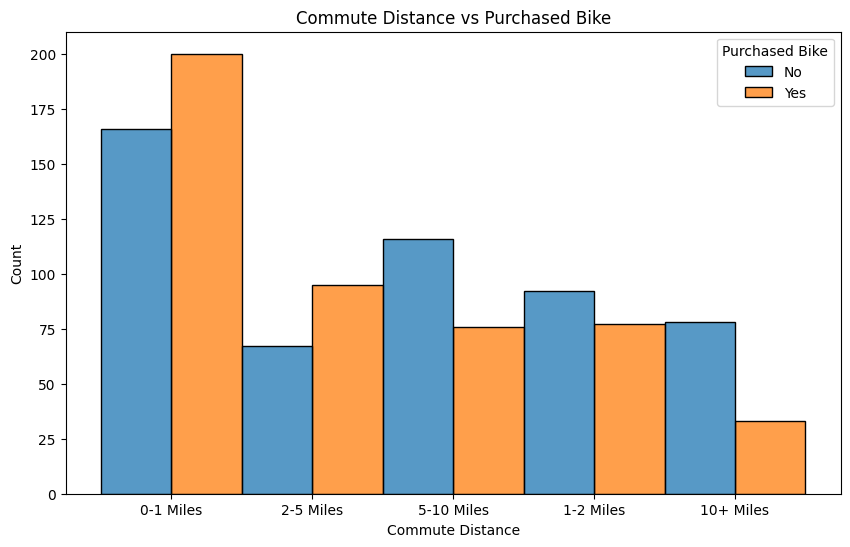

In [29]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Commute Distance", hue="Purchased Bike", multiple="dodge")
plt.title("Commute Distance vs Purchased Bike") # Corrected title
plt.xlabel("Commute Distance") # Corrected x-label
plt.ylabel("Count") # Added y-label for clarity
plt.show()

Customer Purchase Behavior by Age Group

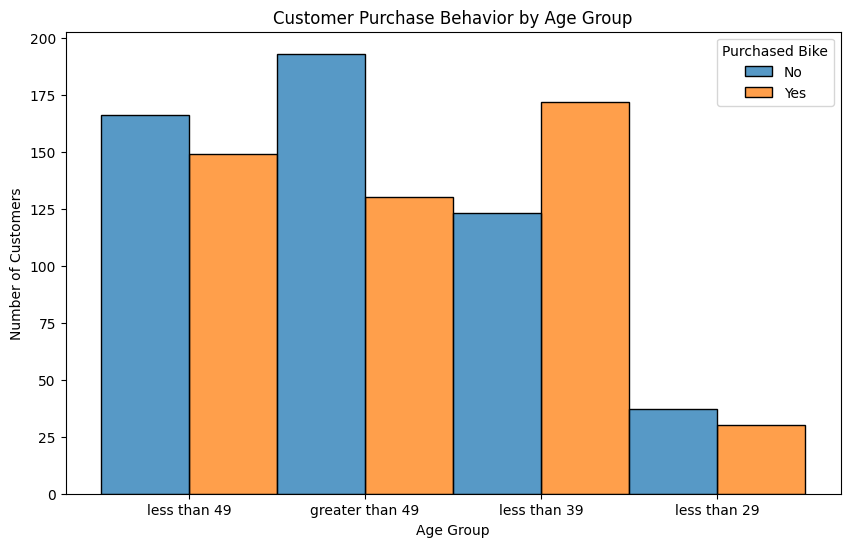

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='Age Group',hue='Purchased Bike',multiple='dodge')
plt.title("Customer Purchase Behavior by Age Group")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.ylabel("Number of Customers")
plt.show()

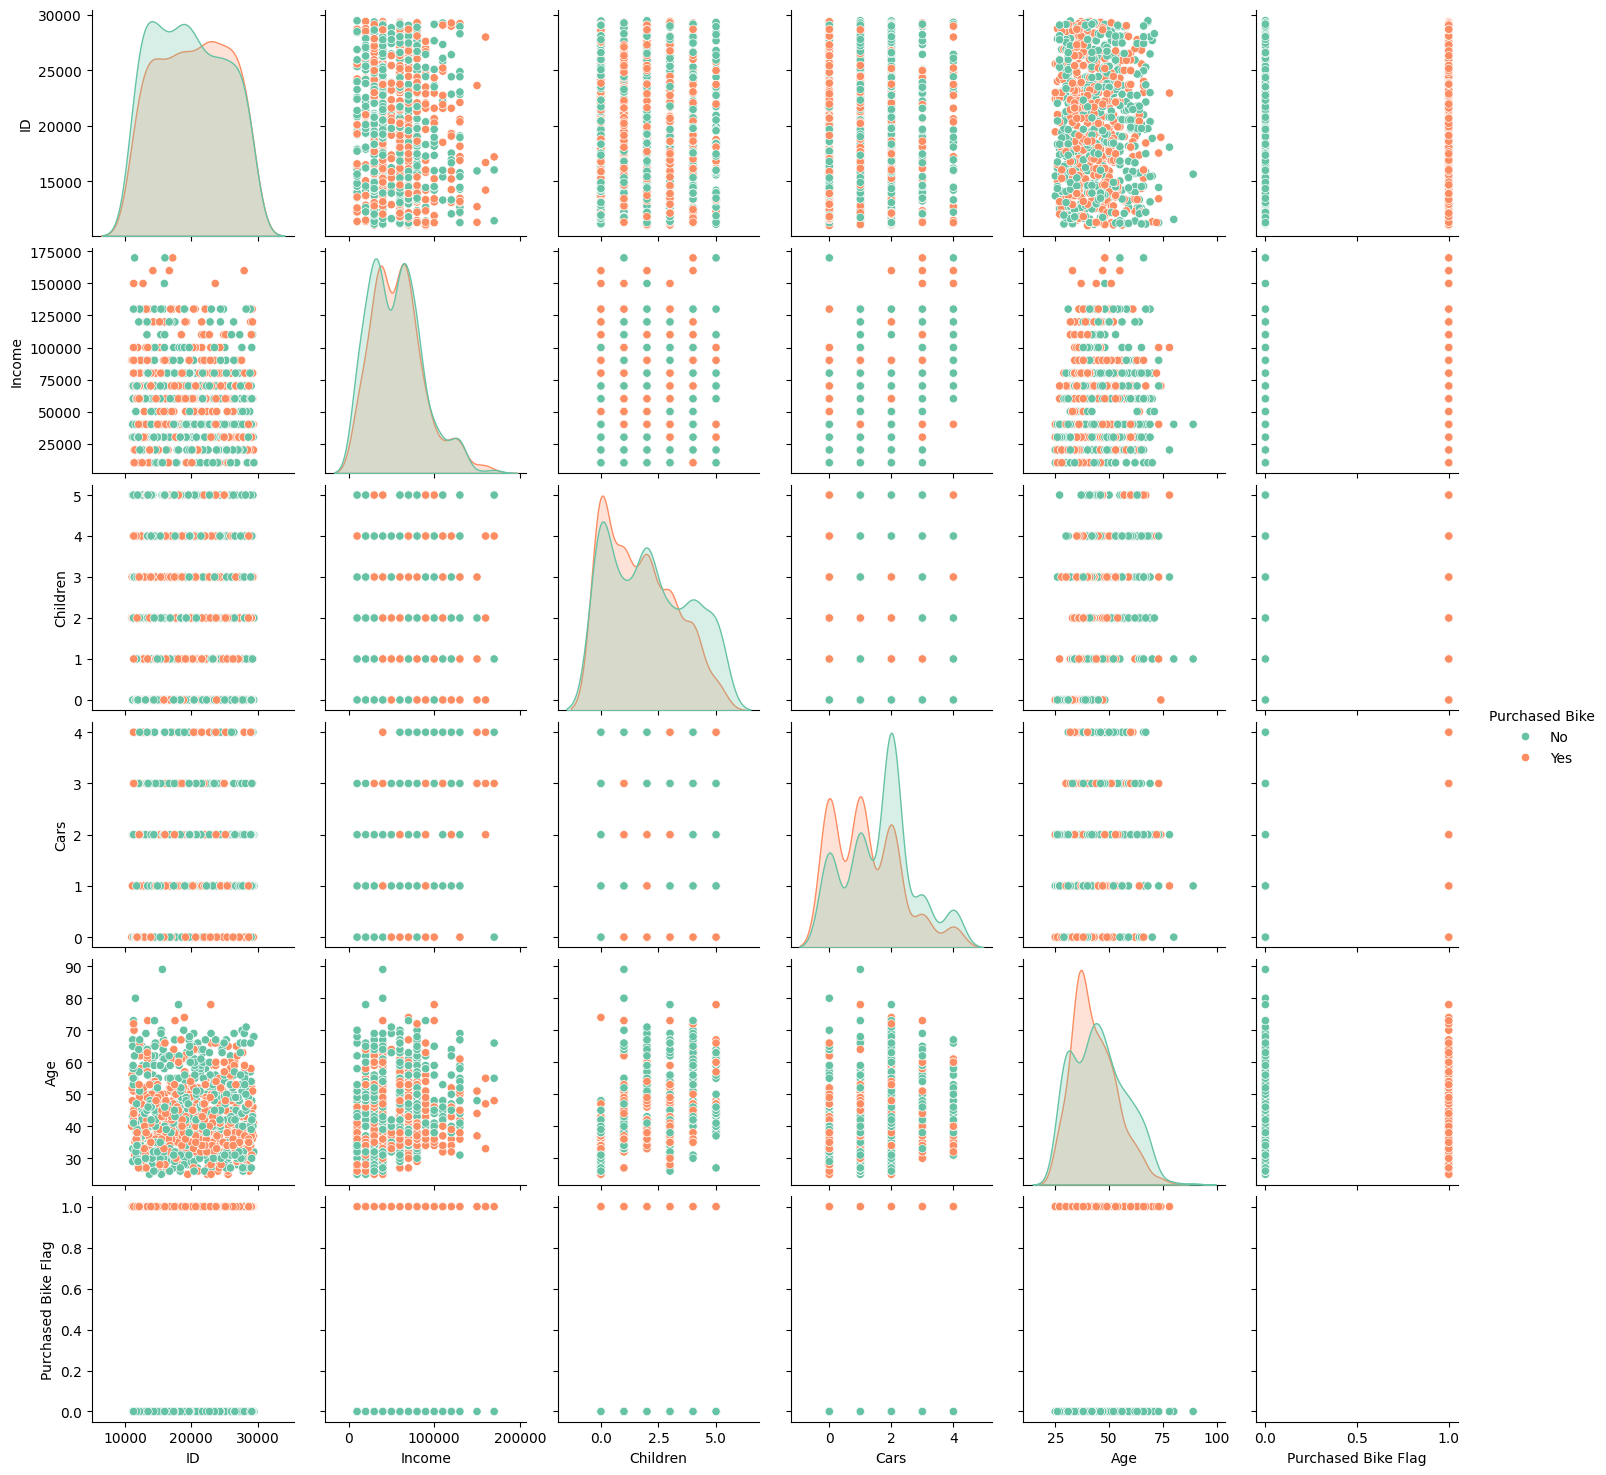

In [41]:
sns.pairplot(data=df,hue='Purchased Bike',palette='Set2')
plt.show()

Key Findings

• Middle-aged customers purchased bikes most frequently.
• Higher-income customers showed greater purchasing behavior.
• Region North America had the highest number of bike purchases.




Business Recommendation

The company should target middle-aged and higher-income customers through personalized marketing campaigns.